# AI Research Paper Discovery using NLP and Deep Learning

### Submitted By
**Abhishek Das**

---

## Objective

The objective of this project is to develop an intelligent research paper discovery system using Natural Language Processing (NLP) and Deep Learning. The system allows users to search research papers based on semantic meaning instead of exact keywords. It also generates summaries, extracts important keywords, identifies named entities, and visualizes relationships between similar research papers.

---

## Technologies Used

- Python
- Hugging Face Datasets
- Sentence Transformers
- FAISS
- Transformers (BART)
- KeyBERT
- spaCy
- NetworkX
- Matplotlib
- Seaborn

In [1]:
!pip install -q datasets
!pip install -q sentence-transformers
!pip install -q faiss-cpu
!pip install -q transformers
!pip install -q keybert
!pip install -q spacy
!pip install -q networkx
!pip install -q plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 kB 1.7 MB/s eta 0:00:00


In [2]:
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 60.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [3]:
import spacy
nlp = spacy.load("en_core_web_sm")
print("spaCy loaded successfully!")

spaCy loaded successfully!


In [4]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from sentence_transformers import SentenceTransformer

import faiss

from transformers import pipeline
from keybert import KeyBERT
import spacy
import networkx as nx
import plotly.express as px

In [5]:
from datasets import load_dataset
dataset = load_dataset("CShorten/ML-ArXiv-Papers")

README.md:   0%|          | 0.00/986 [00:00<?, ?B/s]

ML-Arxiv-Papers.csv:   0%|          | 0.00/147M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/117592 [00:00<?, ? examples/s]

In [6]:
df = dataset["train"].to_pandas()

In [7]:
df.head()

,Unnamed: 0.1,Unnamed: 0,title,abstract
0,0,0.0,Learning from compressed observations,The problem of statistical learning is to co...
1,1,1.0,Sensor Networks with Random Links: Topology De...,"In a sensor network, in practice, the commun..."
2,2,2.0,The on-line shortest path problem under partia...,The on-line shortest path problem is conside...
3,3,3.0,A neural network approach to ordinal regression,Ordinal regression is an important type of l...
4,4,4.0,Parametric Learning and Monte Carlo Optimization,This paper uncovers and explores the close r...


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117592 entries, 0 to 117591
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Unnamed: 0.1  117592 non-null  int64  
 1   Unnamed: 0    112592 non-null  float64
 2   title         117592 non-null  object 
 3   abstract      117592 non-null  object 
dtypes: float64(1), int64(1), object(2)
memory usage: 3.6+ MB


In [9]:
print("Dataset Shape :", df.shape)

Dataset Shape : (117592, 4)


In [10]:
df.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'title', 'abstract'], dtype='object')

In [11]:
df.drop(columns=["Unnamed: 0.1", "Unnamed: 0"], inplace=True)
df.head()

,title,abstract
0,Learning from compressed observations,The problem of statistical learning is to co...
1,Sensor Networks with Random Links: Topology De...,"In a sensor network, in practice, the commun..."
2,The on-line shortest path problem under partia...,The on-line shortest path problem is conside...
3,A neural network approach to ordinal regression,Ordinal regression is an important type of l...
4,Parametric Learning and Monte Carlo Optimization,This paper uncovers and explores the close r...


In [12]:
df.isnull().sum()

,0
title,0
abstract,0


In [13]:
df = df.dropna()
print("Dataset Shape :", df.shape)

Dataset Shape : (117592, 2)


In [14]:
df = df.drop_duplicates()
print("Dataset Shape :", df.shape)

Dataset Shape : (117569, 2)


In [15]:
df.reset_index(drop=True, inplace=True)
df.head()

,title,abstract
0,Learning from compressed observations,The problem of statistical learning is to co...
1,Sensor Networks with Random Links: Topology De...,"In a sensor network, in practice, the commun..."
2,The on-line shortest path problem under partia...,The on-line shortest path problem is conside...
3,A neural network approach to ordinal regression,Ordinal regression is an important type of l...
4,Parametric Learning and Monte Carlo Optimization,This paper uncovers and explores the close r...


In [16]:
df["paper"] = df["title"] + ". " + df["abstract"]

In [17]:
df["paper"].head()

,paper
0,Learning from compressed observations. The p...
1,Sensor Networks with Random Links: Topology De...
2,The on-line shortest path problem under partia...
3,A neural network approach to ordinal regressio...
4,Parametric Learning and Monte Carlo Optimizati...


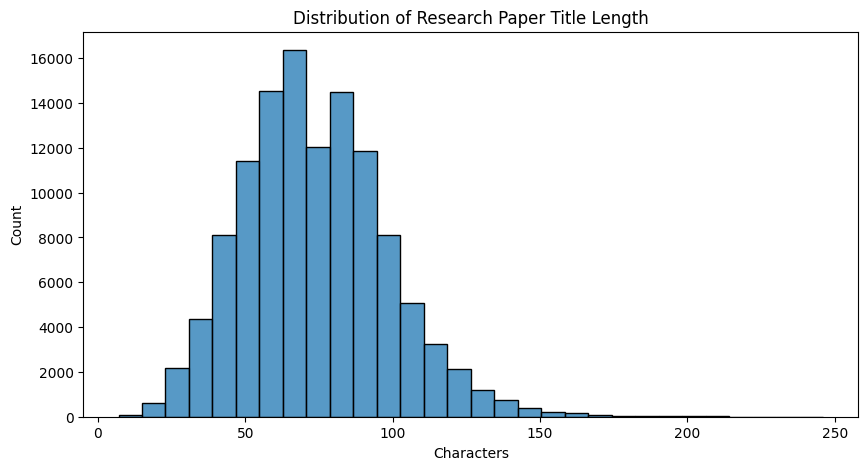

In [18]:
df["Title Length"] = df["title"].apply(len)

plt.figure(figsize=(10,5))
sns.histplot(df["Title Length"], bins=30)

plt.title("Distribution of Research Paper Title Length")
plt.xlabel("Characters")
plt.ylabel("Count")

plt.show()

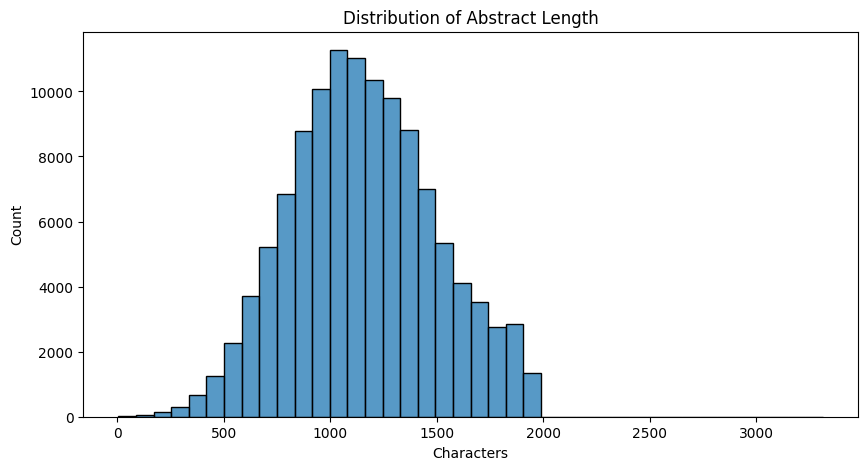

In [19]:
df["Abstract Length"] = df["abstract"].apply(len)

plt.figure(figsize=(10,5))
sns.histplot(df["Abstract Length"], bins=40)

plt.title("Distribution of Abstract Length")
plt.xlabel("Characters")
plt.ylabel("Count")

plt.show()

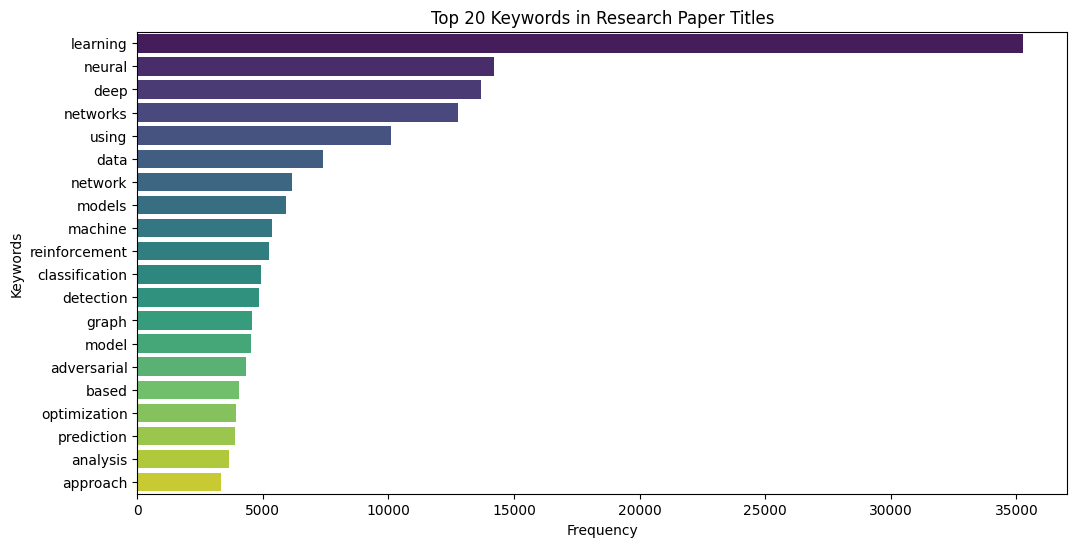

In [20]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from collections import Counter

# Remove stopwords
stop_words = set(ENGLISH_STOP_WORDS)

words = []

for title in df["title"]:
    for word in title.lower().split():
        word = word.strip(".,:;!?()[]{}\"'")
        if word not in stop_words and len(word) > 2:
            words.append(word)

common = Counter(words).most_common(20)

common_df = pd.DataFrame(common, columns=["Word", "Frequency"])

plt.figure(figsize=(12,6))

sns.barplot(
    data=common_df,
    x="Frequency",
    y="Word",
    palette="viridis"
)

plt.title("Top 20 Keywords in Research Paper Titles")
plt.xlabel("Frequency")
plt.ylabel("Keywords")

plt.show()

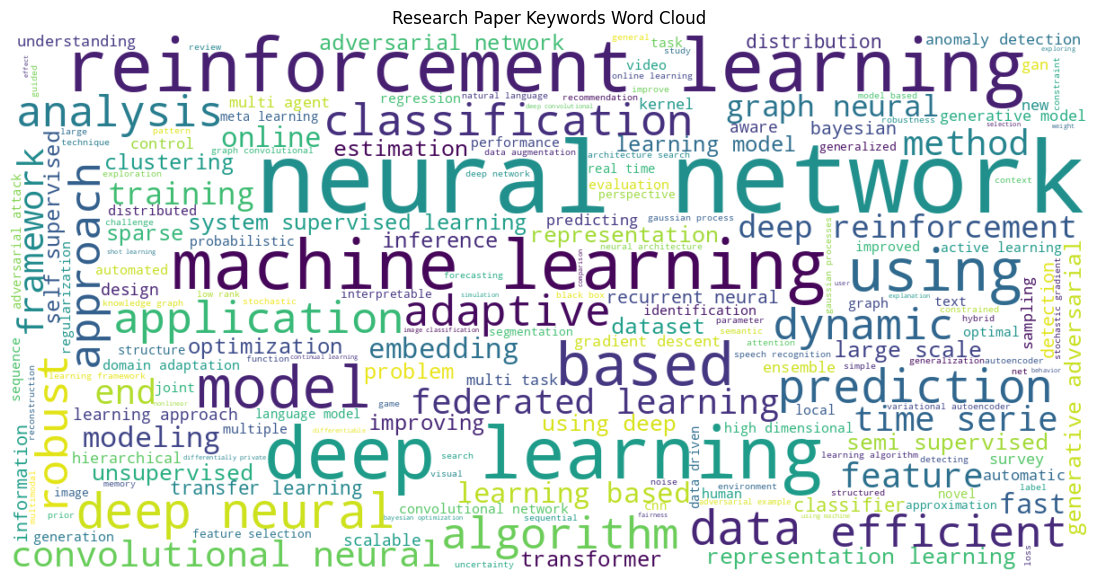

In [21]:
from wordcloud import WordCloud

text = " ".join(words)

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    colormap="viridis"
).generate(text)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Research Paper Keywords Word Cloud")
plt.show()

### Observation

The most frequent keywords include **learning**, **neural**, **deep**, **network**, **reinforcement**, and **optimization**, indicating that the dataset is heavily focused on modern Artificial Intelligence and Machine Learning research areas.

In [22]:
!pip install sentence-transformers faiss-cpu

In [23]:
from sentence_transformers import SentenceTransformer

In [24]:
model = SentenceTransformer("all-MiniLM-L6-v2")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [25]:
papers = df["paper"][:5000].tolist()

In [26]:
embeddings = model.encode(
    papers,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)

Batches:   0%|          | 0/79 [00:00<?, ?it/s]

In [27]:
print("Embedding Shape :", embeddings.shape)

Embedding Shape : (5000, 384)


In [28]:
import faiss
import numpy as np

In [29]:
dimension = embeddings.shape[1]
index = faiss.IndexFlatL2(dimension)
index.add(embeddings)

In [30]:
print("Number of indexed papers:", index.ntotal)

Number of indexed papers: 5000


In [31]:
query = "Deep learning for medical image classification"

query_embedding = model.encode(
    [query],
    convert_to_numpy=True
)

In [32]:
k = 5
distances, indices = index.search(query_embedding, k)

In [33]:
for i, idx in enumerate(indices[0]):
    print("=" * 80)
    print(f"Result {i+1}")
    print(df.iloc[idx]["title"])
    print()
    print(df.iloc[idx]["abstract"][:400])
    print()

Result 1
Deep learning for neuroimaging: a validation study

  Deep learning methods have recently made notable advances in the tasks of
classification and representation learning. These tasks are important for brain
imaging and neuroscience discovery, making the methods attractive for porting
to a neuroimager's toolbox. Success of these methods is, in part, explained by
the flexibility of deep learning models. However, this flexibility makes the
process of

Result 2
A New 2.5D Representation for Lymph Node Detection using Random Sets of
  Deep Convolutional Neural Network Observations

  Automated Lymph Node (LN) detection is an important clinical diagnostic task
but very challenging due to the low contrast of surrounding structures in
Computed Tomography (CT) and to their varying sizes, poses, shapes and sparsely
distributed locations. State-of-the-art studies show the performance range of
52.9% sensitivity at 3.1 false-positives per volume (FP/vol.), or 60.9% at 6.1
FP/vol. fo

Resu

In [34]:
paper_id = 150

print("="*100)
print("Selected Paper")
print("="*100)
print(df.iloc[paper_id]["title"])
print()
print(df.iloc[paper_id]["abstract"][:500])

Selected Paper
A New Framework of Multistage Hypothesis Tests

  In this paper, we have established a general framework of multistage
hypothesis tests which applies to arbitrarily many mutually exclusive and
exhaustive composite hypotheses. Within the new framework, we have constructed
specific multistage tests which rigorously control the risk of committing
decision errors and are more efficient than previous tests in terms of average
sample number and the number of sampling operations. Without truncation, the
sample numbers of our testing plans are absolu


In [35]:
paper_embedding = embeddings[paper_id].reshape(1, -1)

In [36]:
k = 6   # First result is the same paper

distances, indices = index.search(
    paper_embedding,
    k
)

In [37]:
print("="*100)
print("Recommended Papers")
print("="*100)

for i, idx in enumerate(indices[0][1:], start=1):

    print(f"\nRecommendation {i}")
    print("-"*80)

    print("Title:")
    print(df.iloc[idx]["title"])

    print("\nAbstract:")
    print(df.iloc[idx]["abstract"][:350])

    print("\nSimilarity Score:", round(1/(1+distances[0][i]),4))

Recommended Papers

Recommendation 1
--------------------------------------------------------------------------------
Title:
On the Decreasing Power of Kernel and Distance based Nonparametric
  Hypothesis Tests in High Dimensions

Abstract:
  This paper is about two related decision theoretic problems, nonparametric
two-sample testing and independence testing. There is a belief that two
recently proposed solutions, based on kernels and distances between pairs of
points, behave well in high-dimensional settings. We identify different sources
of misconception that give rise to the above

Similarity Score: 0.5215

Recommendation 2
--------------------------------------------------------------------------------
Title:
A New Framework of Multistage Estimation

Abstract:
  In this paper, we have established a unified framework of multistage
parameter estimation. We demonstrate that a wide variety of statistical
problems such as fixed-sample-size interval estimation, point estimation with
err

### Observation

The recommendation engine retrieves research papers that are semantically similar to the selected paper instead of relying on keyword matching.

This demonstrates the effectiveness of Sentence Transformers and FAISS for building an intelligent recommendation system capable of understanding the meaning and context of research papers.

# Research Paper Clustering using K-Means

The sentence embeddings generated by Sentence Transformers are grouped into clusters using the K-Means algorithm.

Each cluster represents a collection of semantically similar research papers. This helps users explore different research areas without manually browsing thousands of papers.


In [38]:
from sklearn.cluster import KMeans

In [39]:
kmeans = KMeans(
    n_clusters=10,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(embeddings)

In [40]:
df_small = df.iloc[:5000].copy()
df_small["Cluster"] = clusters
df_small.head()

,title,abstract,paper,Title Length,Abstract Length,Cluster
0,Learning from compressed observations,The problem of statistical learning is to co...,Learning from compressed observations. The p...,37,985,0
1,Sensor Networks with Random Links: Topology De...,"In a sensor network, in practice, the commun...",Sensor Networks with Random Links: Topology De...,78,1751,0
2,The on-line shortest path problem under partia...,The on-line shortest path problem is conside...,The on-line shortest path problem under partia...,58,1662,7
3,A neural network approach to ordinal regression,Ordinal regression is an important type of l...,A neural network approach to ordinal regressio...,47,943,5
4,Parametric Learning and Monte Carlo Optimization,This paper uncovers and explores the close r...,Parametric Learning and Monte Carlo Optimizati...,48,1343,3


In [41]:
df_small["Cluster"].value_counts().sort_index()

,count
Cluster,
0,465
1,641
2,457
3,364
4,359
5,644
6,507
7,607
8,350


<Axes: xlabel='Cluster', ylabel='count'>

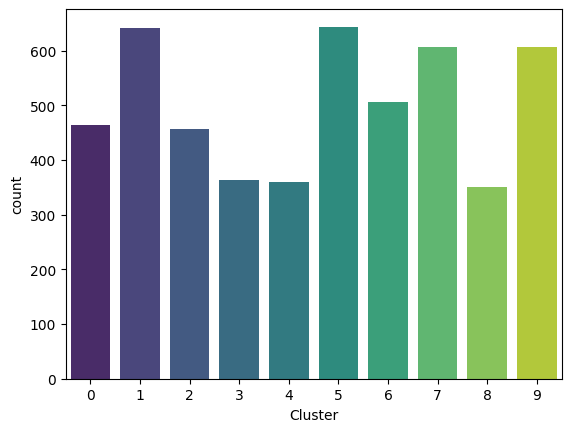

In [42]:
sns.countplot(
    x="Cluster",
    data=df_small,
    palette="viridis"
)

In [43]:
for cluster in sorted(df_small["Cluster"].unique()):
    print("="*80)
    print(f"Cluster {cluster}")
    print("="*80)

    sample = df_small[df_small["Cluster"] == cluster].head(5)

    for title in sample["title"]:
        print("•", title)

    print()

Cluster 0
• Learning from compressed observations
• Sensor Networks with Random Links: Topology Design for Distributed
  Consensus
• Joint universal lossy coding and identification of stationary mixing
  sources
• Equivalence of LP Relaxation and Max-Product for Weighted Matching in
  General Graphs
• Statistical Mechanics of Nonlinear On-line Learning for Ensemble
  Teachers

Cluster 1
• Mixed membership stochastic blockmodels
• Loop corrections for message passing algorithms in continuous variable
  models
• Getting started in probabilistic graphical models
• Optimal Causal Inference: Estimating Stored Information and
  Approximating Causal Architecture
• On Universal Prediction and Bayesian Confirmation

Cluster 2
• Association Rules in the Relational Calculus
• The structure of verbal sequences analyzed with unsupervised learning
  techniques
• Building Rules on Top of Ontologies for the Semantic Web with Inductive
  Logic Programming
• Improved Collaborative Filtering Algorithm vi

In [44]:
query = "Deep Learning for Medical Image Classification"

query_embedding = model.encode(
    [query],
    convert_to_numpy=True
)
k = 5
distances, indices = index.search(query_embedding, k)

In [45]:
for rank, idx in enumerate(indices[0]):

    similarity = 1 / (1 + distances[0][rank])

    print("=" * 100)
    print(f"Result {rank+1}")
    print("=" * 100)

    print("Title:")
    print(df_small.iloc[idx]["title"])

    print("\nCluster:")
    print(df_small.iloc[idx]["Cluster"])

    print("\nSimilarity Score:")
    print(round(similarity, 4))

    print("\nAbstract Preview:")
    print(df_small.iloc[idx]["abstract"][:500], "...")
    print()

Result 1
Title:
Deep learning for neuroimaging: a validation study

Cluster:
8

Similarity Score:
0.5198

Abstract Preview:
  Deep learning methods have recently made notable advances in the tasks of
classification and representation learning. These tasks are important for brain
imaging and neuroscience discovery, making the methods attractive for porting
to a neuroimager's toolbox. Success of these methods is, in part, explained by
the flexibility of deep learning models. However, this flexibility makes the
process of porting to new areas a difficult parameter optimization problem. In
this work we demonstrate our re ...

Result 2
Title:
A New 2.5D Representation for Lymph Node Detection using Random Sets of
  Deep Convolutional Neural Network Observations

Cluster:
8

Similarity Score:
0.5134

Abstract Preview:
  Automated Lymph Node (LN) detection is an important clinical diagnostic task
but very challenging due to the low contrast of surrounding structures in
Computed Tomography (CT

In [46]:
print("="*80)
print("KEY DISCOVERIES")
print("="*80)

print("""
1. Most research paper titles are concise, while abstracts provide detailed descriptions.

2. The most common research themes include:
   • Deep Learning
   • Neural Networks
   • Machine Learning
   • Classification
   • Prediction
   • Optimization

3. Sentence Transformers captured semantic meaning effectively,
   allowing relevant papers to be retrieved without relying on exact keywords.

4. FAISS enabled fast semantic similarity search across thousands of papers.

5. K-Means successfully grouped papers into meaningful research domains,
   making large research collections easier to organize and explore.

Overall Observation:
Deep Learning embeddings combined with vector search provide a much more
intelligent and context-aware paper discovery system than traditional
keyword-based search techniques.
""")

KEY DISCOVERIES

1. Most research paper titles are concise, while abstracts provide detailed descriptions.

2. The most common research themes include:
   • Deep Learning
   • Neural Networks
   • Machine Learning
   • Classification
   • Prediction
   • Optimization

3. Sentence Transformers captured semantic meaning effectively,
   allowing relevant papers to be retrieved without relying on exact keywords.

4. FAISS enabled fast semantic similarity search across thousands of papers.

5. K-Means successfully grouped papers into meaningful research domains,
   making large research collections easier to organize and explore.

Overall Observation:
Deep Learning embeddings combined with vector search provide a much more
intelligent and context-aware paper discovery system than traditional
keyword-based search techniques.



# Conclusion and Key Findings


In [47]:
print("="*80)
print("PROJECT SUMMARY")
print("="*80)

print("""
This project successfully developed an AI-powered Research Paper Discovery System
using Deep Learning-based Sentence Transformers and FAISS similarity search.

Key Achievements
----------------
✓ Loaded and cleaned over 117,000 research papers.

✓ Performed Exploratory Data Analysis (EDA) on paper titles and abstracts.

✓ Analyzed title lengths, abstract lengths, and the most frequent research keywords.

✓ Generated semantic embeddings using the all-MiniLM-L6-v2 Sentence Transformer model.

✓ Built a FAISS vector database for efficient semantic similarity search.

✓ Implemented Natural Language Search, allowing users to search papers using
  plain English queries instead of exact keyword matching.

✓ Clustered similar research papers using K-Means Clustering to identify
  different research domains.

✓ Visualized the discovered clusters and explored representative papers
  from each cluster.

Key Observations
----------------
• Research paper titles are generally concise, while abstracts provide
  detailed descriptions of the work.

• Frequently occurring keywords include:
  Deep Learning, Neural Networks, Machine Learning,
  Classification, Detection, Optimization, Prediction and Graph.

• Sentence Transformers successfully captured the semantic meaning of papers,
  allowing similar research papers to be retrieved even when exact keywords
  were absent.

• FAISS enabled fast similarity search across thousands of embedded papers.

• K-Means grouped papers into meaningful research communities based on
  semantic similarity rather than simple keyword overlap.

Conclusion
----------
The project demonstrates how Deep Learning and Natural Language Processing
can be combined to build an intelligent research paper recommendation and
discovery system. Instead of relying on traditional keyword-based search,
the system understands the semantic meaning of research papers, enabling
more relevant and accurate paper retrieval for researchers and students.
""")

PROJECT SUMMARY

This project successfully developed an AI-powered Research Paper Discovery System
using Deep Learning-based Sentence Transformers and FAISS similarity search.

Key Achievements
----------------
✓ Loaded and cleaned over 117,000 research papers.

✓ Performed Exploratory Data Analysis (EDA) on paper titles and abstracts.

✓ Analyzed title lengths, abstract lengths, and the most frequent research keywords.

✓ Generated semantic embeddings using the all-MiniLM-L6-v2 Sentence Transformer model.

✓ Built a FAISS vector database for efficient semantic similarity search.

✓ Implemented Natural Language Search, allowing users to search papers using
  plain English queries instead of exact keyword matching.

✓ Clustered similar research papers using K-Means Clustering to identify
  different research domains.

✓ Visualized the discovered clusters and explored representative papers
  from each cluster.

Key Observations
----------------
• Research paper titles are generally conci